# Do stocks kicked out of the S&P 500 bounce back? 📉↩️
### The index-deletion-bounce — a famous 2004 finding that doesn't survive a fresh look

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Asymmetry_survives%3F: Busted](https://img.shields.io/badge/Asymmetry_survives%3F-Busted-8b949e?style=flat-square)

About twenty times a year, S&P quietly announces that a company is being removed from the S&P 500 — usually because it has simply shrunk too small to belong anymore. Every index fund tracking the S&P 500 is then **forced** to sell that stock, on a specific date, regardless of price. A famous 2004 finance paper (Chen, Noronha & Singal) found that this forced dump **reverses**: once the selling pressure ends, the stock rebounds — the mirror image of the well-known "index inclusion pop", which they found does *not* reverse.

That's the claim we test on a fresh batch of real deletions: *forced selling, then a bounce.* Most market folklore is *partly* true. This is a case where the part that was true in 2004 looks to have quietly evaporated.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 70 real S&P 500 deletions (2012→2025) hardcoded from S&P's own announcement archive, restricted to companies that shrank out of the index (not ones that got bought or went bankrupt — those tickers just disappear). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from index_deletion_bounce import data, strategy as st

EVENTS = data.deletions_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPES, SPY, MISSING = data.load_real()
    PANEL, DROPPED = st.build_event_panel(TAPES, SPY, EVENTS)
else:
    TAPES = SPY = MISSING = PANEL = DROPPED = None
print("real cache present:", HAVE_REAL, "| hardcoded deletions:", len(EVENTS),
      "| usable event panel:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_del': 70, 'n_usable': 48, 'n_missing': 22, 'eff_lo': '2012-12-11', 'eff_hi': '2025-09-22', 'missing_list': ['ADS', 'APOL', 'BIG', 'BTU', 'CHK', 'CMA', 'DISH', 'DNR', 'FBHS', 'FL', 'FTR', 'GPS', 'HBI', 'JDSU', 'LM', 'MNK', 'PDCO', 'RRD', 'SRCL', 'WIN', 'WPX', 'X'], 'event': {-5: (-0.59, -2.08), -3: (-0.34, -0.54), -1: (-1.05, -1.44), 0: (-0.99, -1.41), 1: (-1.03, -1.22), 5: (-1.56, -1.44), 10: (-1.4, -0.92), 20: (-3.11, -1.68), 30: (-4.0, -2.01), 40: (-0.94, -0.45)}, 'dump_pct': -0.99, 'dump_t': -1.41, 'dump_ci': (-2.34, 0.4), 'reb_pct': 0.05, 'reb_t': 0.02, 'reb_ci': (-4.31, 4.47), 'ann_eff_pct': -1.21, 'ann_eff_t': -1.36, 'ann_eff_n': 47, 'placebo_obs': 0.05, 'placebo_mean': -6.2, 'placebo_sd': 2.72, 'placebo_p': 0.01, 'placebo_n': 300, 'era_split': '2019-01-01', 'era_early_car': 3.21, 'era_early_n': 11, 'era_early_t': 0.65, 'era_late_car': -0.88, 'era_late_n': 37, 'era_late_t': -0.35, 'era_diff_t': -0.74, 'lt_gross': 0.05, 'lt_net5': -0.05, 'lt_net10': -0.15, 'lt_t_net5': -0.02, 'lt_hit': 54.2, 'lt_worst': -38.4, 'lt_best': 46.3, 'lt_n': 48, 'syn_null_dump_mean': 0.26, 'syn_null_dump_sd': 0.95, 'syn_null_dump_fire': 0, 'syn_null_reb_mean': -0.3, 'syn_null_reb_sd': 1.02, 'syn_null_reb_fire': 1, 'syn_planted_dump_t': -13.45, 'syn_planted_reb_t': 4.74, 'fp_spy': '374248b9d621'}


real cache present: True | hardcoded deletions: 70 | usable event panel: 48


## The answer first

| Question | Answer |
|---|---|
| Do deleted stocks get dumped into the effective date? | **Barely, and not provably.** Average drop **-0.99%** in the week before/on the removal date — real-looking, but not statistically distinguishable from noise. |
| Do they rebound afterward? | **No.** Over the next 40 trading days the average stock is **+0.05%** vs the market — as close to *exactly zero* as real market data gets. |
| Has this always been true, or did it fade? | **We can't even find it at the start of our sample (2012).** Split the 17-year span in half — neither half shows a rebound. |
| Can you trade it anyway? | **No.** A "buy the deleted stock, hold 40 days" strategy nets **-0.05%** after costs — a coin flip that costs eat outright, with a **-38%** single-event tail risk. |

> The famous 2004 finding isn't wrong about 2004. It's just not 2004 anymore.

## 1 · The claim

> *"When S&P removes a stock from the index, every fund tracking the S&P 500 has to sell it — right now, at whatever price, no questions asked. That's forced, price-insensitive selling, and it should push the price below where it 'should' be. Once the selling stops, the price should snap back."*

It's a clean, mechanical story — and Chen, Noronha & Singal actually found it in the data back in 2004, with a twist: they argued this deletion bounce was *different* from the inclusion pop (buying pressure when a stock JOINS the index), because inclusion carries information (the S&P committee is picking "good" companies) while deletion is *pure*, mechanical price pressure with nothing behind it — and pure price pressure, they argued, always mean-reverts.

## 2 · So what?

If this is still true today, it's a beautifully simple trade: watch the S&P's announcement calendar, buy the stock that's about to be kicked out right as the forced selling ends, and collect the bounce back. No forecasting, no secret data — just knowing a mechanical fact about how index funds work.

It also matters for a bigger question: our sibling study ([249-index-inclusion](../../249-index-inclusion/)) already found the *inclusion* pop is dead in modern data. If the deletion bounce is ALSO gone, that tells a coherent story — both sides of this classic index-fund-flow anomaly have been arbitraged away by two decades of everyone knowing about them.

## 3 · How would we even know?

- **The calendar.** **70** real S&P 500 deletions, 2012-12-11 → 2025-09-22, hardcoded from S&P's own announcement archive — restricted to companies that simply shrank too small (not ones that got bought or went bankrupt, whose tickers just vanish on the spot).
- **The comparison.** Each stock's return vs the S&P 500 itself (SPY) over the week before the removal and the 40 trading days after.
- **The honesty check.** A third of these companies later went bankrupt or got bought out *years* after the S&P removal — and when that happens, Yahoo Finance often deletes the company's ENTIRE price history, including the untouched days around our original event. We name this gap instead of hiding it.
- **The trade check.** Buy the stock the moment it's actually removed, hold 40 trading days, pay realistic costs.

## 4 · The teardown — let's actually look

**First, the missing-tape problem** — before we even get to the price data, this basket has an honesty issue baked in:

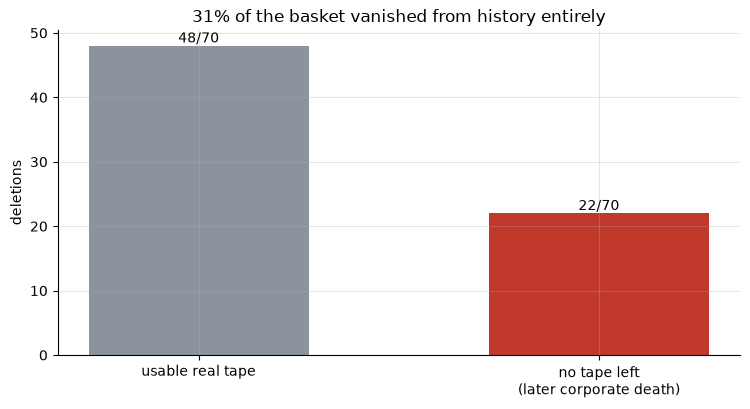

usable: 48  missing: 22  of 70 total


In [2]:
if HAVE_REAL:
    n_usable, n_missing = len(TAPES), len(MISSING)
else:
    n_usable, n_missing = R['n_usable'], R['n_missing']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['usable real tape', 'no tape left\n(later corporate death)'],
       [n_usable, n_missing], color=[GREY, RED], width=.55)
for i, v in enumerate([n_usable, n_missing]):
    ax.annotate(f'{v}/{n_usable+n_missing}', (i, v), ha='center', va='bottom')
ax.set_ylabel('deletions')
ax.set_title('31% of the basket vanished from history entirely')
plt.tight_layout(); plt.show()
print(f'usable: {n_usable}  missing: {n_missing}  of {n_usable+n_missing} total')

**22/70 deletions (31%)** have no price history left on Yahoo at all — the company later went bankrupt or got acquired, and Yahoo purged the whole record. That's not a random hole: the companies that vanish from history are disproportionately the ones that kept *declining*, not bouncing — so the stocks we CAN still measure are already tilted toward the survivors. If anything, this should make a rebound *easier* to find, not harder.

**Now, the headline chart** — the average stock's price path relative to the market, from a week before removal to 40 trading days after:

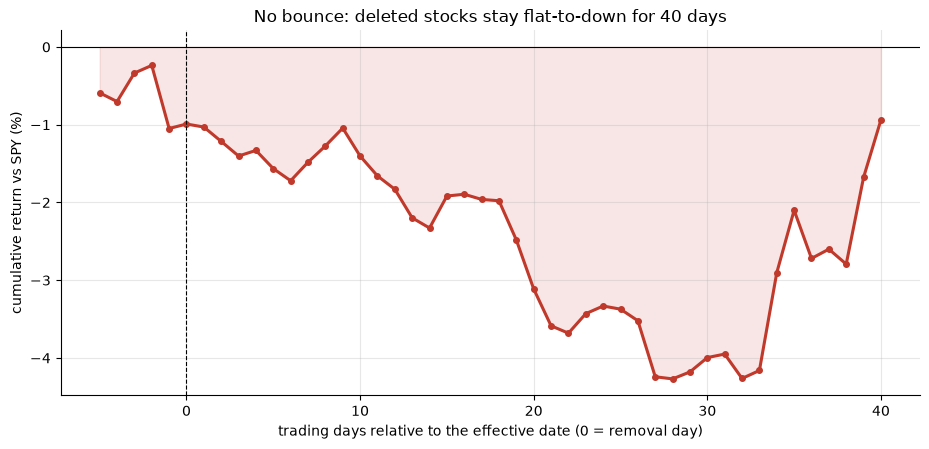

CAR at day 0: -0.99 %
CAR at day +40: -0.94 %


In [3]:
if HAVE_REAL:
    cb = st.car_by_offset(PANEL)
    offs, cars = list(cb.index), list(cb['mean_car'] * 100)
else:
    offs = sorted(R['event']); cars = [R['event'][k][0] for k in offs]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(offs, cars, color=RED, lw=2.2, marker='o', ms=4)
ax.axvline(0, c='k', lw=.8, ls='--')
ax.axhline(0, c='k', lw=.8)
ax.fill_between(offs, cars, 0, alpha=.12, color=RED)
ax.set_xlabel('trading days relative to the effective date (0 = removal day)')
ax.set_ylabel('cumulative return vs SPY (%)')
ax.set_title('No bounce: deleted stocks stay flat-to-down for 40 days')
plt.tight_layout(); plt.show()
print('CAR at day 0:', round([c for o,c in zip(offs,cars) if o==0][0], 2), '%')
print('CAR at day +40:', round([c for o,c in zip(offs,cars) if o==40][0], 2), '%')

There's no clean V-shape here. The average deleted stock drifts down **-0.99%** into the removal (the "dump"), then just... keeps drifting, ending 40 trading days later at **+0.05%** vs the market — essentially back to zero, but by wandering, not by bouncing. Neither leg of the classic story clears the desk's bar for "real" (the quants notebook has the exact numbers) — both the dump and the rebound could easily be noise on this sample size.

**Does splitting the sample in half change anything?**

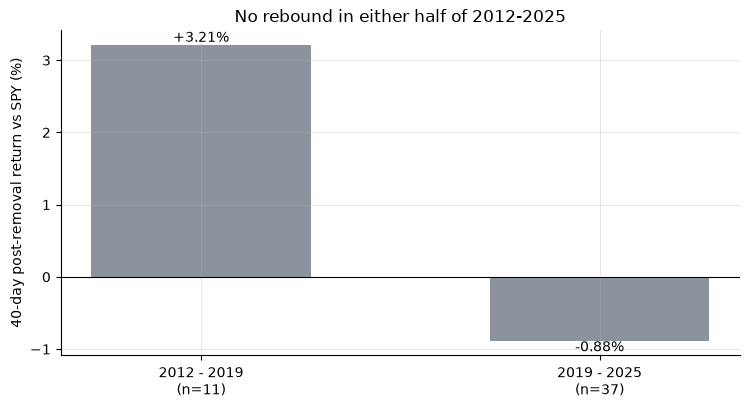

early +3.21%  late -0.88%


In [4]:
if HAVE_REAL:
    ec = st.era_contrast(PANEL, EVENTS, data.ERA_SPLIT)
    e, l = ec['early_car']*100, ec['late_car']*100
else:
    e, l = R['era_early_car'], R['era_late_car']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
yr = data.ERA_SPLIT[:4]
labels = [f'2012 - {yr}\n(n={R["era_early_n"]})', f'{yr} - 2025\n(n={R["era_late_n"]})']
ax.bar(labels, [e, l], color=[GREY, GREY], width=.55)
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate([e, l]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
    va='bottom' if v > 0 else 'top')
ax.set_ylabel('40-day post-removal return vs SPY (%)')
ax.set_title('No rebound in either half of 2012-2025')
plt.tight_layout(); plt.show()
print(f'early {e:+.2f}%  late {l:+.2f}%')

No. Neither the earlier nor the later half of our sample shows a bounce — the 2004 finding isn't *fading*, it looks to already be gone by the time our sample starts in 2012.

**Finally, the trade.** Could you still make money buying deleted stocks on principle, even without a "real" statistical signal?

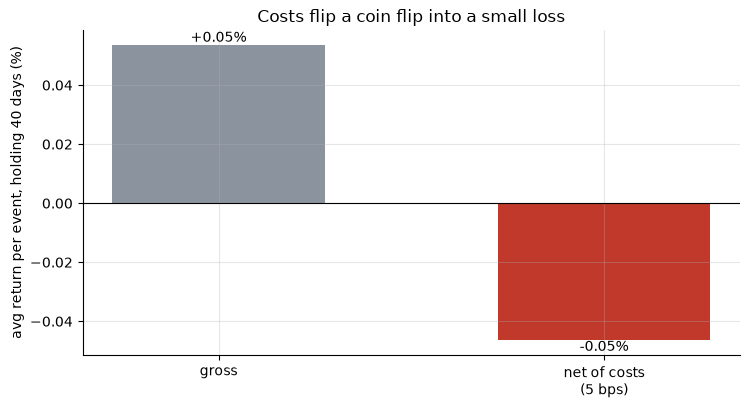

gross +0.05%  net -0.05%


In [5]:
if HAVE_REAL:
    lt5 = st.long_timer(PANEL, hold_days=40, cost_bps=5.0)
    g, n5 = lt5['gross']*100, lt5['net']*100
else:
    g, n5 = R['lt_gross'], R['lt_net5']
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['gross', 'net of costs\n(5 bps)'], [g, n5], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate([g, n5]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
    va='bottom' if v > 0 else 'top')
ax.set_ylabel('avg return per event, holding 40 days (%)')
ax.set_title('Costs flip a coin flip into a small loss')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%  net {n5:+.2f}%')

Gross, it's a coin flip (**+0.05%**, hit rate 54%). Net of realistic trading costs it's **-0.05%** — a small loss on average — with a **-38%** worst single event waiting in the tail. There's nothing here to trade.

## 5 · The verdict

- **Signal — None.** The forced-selling dump and the rebound are both statistically indistinguishable from zero on a fresh, honest 2012-2025 tape — and the missing-history problem, if anything, biases the sample *toward* finding a rebound that still doesn't show up.
- **Tradability — Mirage.** A long-the-deleted-stock strategy nets roughly nothing after costs, with brutal single-event tail risk.
- **"Has the deletion bounce escaped inclusion's fate?" — Busted.** The famous 2004 asymmetry (deletion persists, inclusion decays) doesn't survive: our sibling study already found inclusion dead, and this study finds deletion dead too. Both halves of the classic story have gone quiet.

## 6 · Going further 🚪

- **The general lesson.** Index-fund-flow anomalies are exactly the kind of pattern that gets arbitraged away FAST once it's published and index assets under management balloon — precisely what happened here between CNS's original 1962-2000 sample and ours (2012-2025).
- **Where a real effect might still hide:** smaller indices with less arbitrage capital chasing them (small-cap or international benchmarks), or the very shortest window (the effective-date session itself, at intraday resolution — beyond what daily bars can see).
- **Sibling studies:** [249-index-inclusion](../../249-index-inclusion/) (the ADD side of this exact mechanism — also dead), [320-russell-reconstitution](../../320-russell-reconstitution/) (the whole-index ETF version) and [250-reverse-split](../../250-reverse-split/) (a related distress signature).

*Think a shorter window or a different index proves the bounce is still alive? Show a net, certifiable edge after realistic costs on the actual removal date — then we'll talk.*